# LAB 02 — Experiment 3: Perplexity (Bài 19)

- So sánh Unigram / Bigram / Trigram trên train / valid / test (cùng cách chia 8 : 1 : 1, seed 42 như Experiment 2).
- Đánh giá cả MLE và Laplace: MLE cho thấy overfitting, Laplace cho perplexity hữu hạn để so sánh.
- Thí nghiệm thêm: thay đổi kích thước train để xem tác động của corpus size.
- Giải thích nằm ở file `log_probability.md` (mục 19).

In [ ]:
import copy
import gzip
import json
import math
import random
import re
import sys
from collections import Counter

import pandas as pd

SOS = "<s>"
EOS = "</s>"


def split_sentences(text):
    sentences = re.split(r"[.!?]+", text)
    return [s.strip() for s in sentences if s.strip()]


def tokenize(sentence):
    # sys.intern: cac token giong nhau dung chung 1 object -> tiet kiem RAM
    return [sys.intern(t) for t in re.findall(r"[a-z\u00e0-\u1ef9\u0300-\u036f0-9]+", sentence.lower())]


def load_documents(path, text_field="text", limit=None):
    opener = gzip.open if path.endswith(".gz") else open
    docs = []
    with opener(path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            docs.append(json.loads(line)[text_field] if ".json" in path else line)
            if limit is not None and len(docs) >= limit:
                break
    return docs


def prepare_sentences(docs):
    """docs -> list cac cau, moi cau la list token."""
    sentences = []
    for doc in docs:
        for s in split_sentences(doc):
            tokens = tokenize(s)
            if tokens:
                sentences.append(tokens)
    return sentences

In [ ]:
def build_vocabulary(sentences, min_count=1):
    counts = Counter(w for s in sentences for w in s)
    vocab = {w for w, c in counts.items() if c >= min_count}
    vocab.add(EOS)
    return vocab


def pad_sentence(tokens, n):
    return [SOS] * (n - 1) + list(tokens) + [EOS]


def count_ngrams(sentences, n):
    counts = Counter()
    for tokens in sentences:
        padded = pad_sentence(tokens, n)
        for i in range(len(padded) - n + 1):
            counts[tuple(padded[i:i + n])] += 1
    return counts


def count_contexts(ngram_counts):
    contexts = Counter()
    for ngram, c in ngram_counts.items():
        contexts[ngram[:-1]] += c
    return contexts


class NGramLanguageModel:
    def __init__(self, n, smoothing="none"):
        assert n in (1, 2, 3)
        assert smoothing in ("none", "laplace")
        self.n = n
        self.smoothing = smoothing

    def fit(self, sentences, vocab=None):
        # vocab tuy chon: cho phep co dinh vocabulary khi doi kich thuoc train (Experiment 3)
        self.vocab = vocab if vocab is not None else build_vocabulary(sentences)
        self.ngram_counts = count_ngrams(sentences, self.n)
        self.context_counts = count_contexts(self.ngram_counts)
        return self

    def with_smoothing(self, smoothing):
        other = copy.copy(self)
        other.smoothing = smoothing
        return other

    def _normalize_context(self, context):
        if self.n == 1:
            return ()
        ctx = list(context)[-(self.n - 1):]
        ctx = [SOS] * (self.n - 1 - len(ctx)) + ctx
        return tuple(ctx)

    def probability(self, context, word):
        ctx = self._normalize_context(context)
        count = self.ngram_counts.get(ctx + (word,), 0)
        ctx_count = self.context_counts.get(ctx, 0)
        if self.smoothing == "laplace":
            return (count + 1) / (ctx_count + len(self.vocab))
        if ctx_count == 0:
            return 0.0
        return count / ctx_count

    def perplexity(self, sentences):
        """Tra ve (perplexity, ty le token co xac suat = 0). PPL = inf neu co token xac suat 0."""
        total_logp, N, zeros = 0.0, 0, 0
        for tokens in sentences:
            padded = pad_sentence(tokens, self.n)
            for i in range(self.n - 1, len(padded)):
                p = self.probability(padded[i - self.n + 1:i], padded[i])
                N += 1
                if p == 0.0:
                    zeros += 1
                else:
                    total_logp += math.log(p)
        ppl = float("inf") if zeros else math.exp(-total_logp / N)
        return ppl, zeros / N

## Load corpus và chia train / valid / test = 8 : 1 : 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CORPUS_PATH = "/content/drive/MyDrive/NLP/lab02/c4-train.00000-of-01024-30K.json.gz"
LIMIT = None   # None = full 30K documents
SEED = 42

Mounted at /content/drive


In [ ]:
docs = load_documents(CORPUS_PATH, limit=LIMIT)

idx = list(range(len(docs)))
random.Random(SEED).shuffle(idx)
n_train = int(0.8 * len(idx))
n_valid = int(0.1 * len(idx))

split_docs = {
    "train": [docs[i] for i in idx[:n_train]],
    "valid": [docs[i] for i in idx[n_train:n_train + n_valid]],
    "test":  [docs[i] for i in idx[n_train + n_valid:]],
}
del docs

data = {name: prepare_sentences(d) for name, d in split_docs.items()}
for name in data:
    n_tok = sum(len(s) for s in data[name])
    print(f"{name:5s}: {len(split_docs[name]):6d} docs, {len(data[name]):8d} sentences, {n_tok:9d} tokens")

train:  24000 docs,   551369 sentences,   8949462 tokens
valid:   3000 docs,    67389 sentences,   1071567 tokens
test :   3000 docs,    67083 sentences,   1068310 tokens


## Bảng perplexity: Unigram / Bigram / Trigram × MLE / Laplace

In [ ]:
rows = []
base_models = {}
for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    mle = NGramLanguageModel(n).fit(data["train"])
    base_models[name] = mle
    for smoothing, lm in [("MLE", mle), ("Laplace", mle.with_smoothing("laplace"))]:
        row = {"Model": f"{name} {smoothing}", "Unique n-grams": len(mle.ngram_counts)}
        for split in ("train", "valid", "test"):
            ppl, zero_rate = lm.perplexity(data[split])
            row[f"{split.capitalize()} PPL"] = ppl
            row[f"{split.capitalize()} zero-prob %"] = 100 * zero_rate
        rows.append(row)
        print("done:", row["Model"])

results = pd.DataFrame(rows)
print()
print(results[["Model", "Unique n-grams", "Train PPL", "Valid PPL", "Test PPL"]]
      .to_string(index=False, float_format=lambda x: f"{x:,.1f}"))
print()
print(results[["Model", "Train zero-prob %", "Valid zero-prob %", "Test zero-prob %"]]
      .to_string(index=False, float_format=lambda x: f"{x:.2f}"))

done: Unigram MLE
done: Unigram Laplace
done: Bigram MLE
done: Bigram Laplace
done: Trigram MLE
done: Trigram Laplace

          Model  Unique n-grams  Train PPL  Valid PPL  Test PPL
    Unigram MLE          167124    1,634.0        inf       inf
Unigram Laplace          167124    1,639.4    1,720.1   1,722.8
     Bigram MLE         2419124      161.5        inf       inf
 Bigram Laplace         2419124    5,208.5    6,748.7   6,761.9
    Trigram MLE         5824232       14.7        inf       inf
Trigram Laplace         5824232   28,966.3   47,785.3  48,061.6

          Model  Train zero-prob %  Valid zero-prob %  Test zero-prob %
    Unigram MLE               0.00               1.74              1.83
Unigram Laplace               0.00               0.00              0.00
     Bigram MLE               0.00              21.79             21.99
 Bigram Laplace               0.00               0.00              0.00
    Trigram MLE               0.00              57.38             57.42


## Tác động của corpus size

Giữ nguyên valid set, huấn luyện trên 10% / 25% / 50% / 100% của train. Vocabulary được **cố định** (lấy từ toàn bộ train) để chỉ thay đổi lượng dữ liệu, nếu không V thay đổi theo và làm nhiễu kết quả của Laplace.
Đo: valid perplexity (Laplace) và tỉ lệ token valid có xác suất 0 khi dùng MLE (tức n-gram chưa từng thấy).

In [ ]:
import gc

# Giai phong bo nho truoc khi huan luyen cac model tren tap con
full_stats = results.set_index("Model")
full_vocab = base_models["Unigram"].vocab   # vocabulary co dinh = vocab cua toan bo train
del base_models
gc.collect()

size_rows = []
for frac in (0.1, 0.25, 0.5):
    sub = data["train"][:int(frac * len(data["train"]))]
    n_tok = sum(len(s) for s in sub)
    for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
        mle = NGramLanguageModel(n).fit(sub, vocab=full_vocab)
        ppl_lap, _ = mle.with_smoothing("laplace").perplexity(data["valid"])
        _, zero = mle.perplexity(data["valid"])
        size_rows.append({"Train fraction": frac, "Train tokens": n_tok, "Model": name,
                          "Valid PPL (Laplace)": ppl_lap, "Valid unseen n-gram %": 100 * zero})
        del mle
        gc.collect()
    print(f"done: {int(frac * 100)}%")

# 100% train: lay lai tu bang phia tren (khong huan luyen lai)
n_tok_full = sum(len(s) for s in data["train"])
for name in ("Unigram", "Bigram", "Trigram"):
    size_rows.append({"Train fraction": 1.0, "Train tokens": n_tok_full, "Model": name,
                      "Valid PPL (Laplace)": full_stats.loc[f"{name} Laplace", "Valid PPL"],
                      "Valid unseen n-gram %": full_stats.loc[f"{name} MLE", "Valid zero-prob %"]})

size_df = pd.DataFrame(size_rows)
print()
print(size_df.pivot(index="Train fraction", columns="Model", values="Valid PPL (Laplace)")[["Unigram", "Bigram", "Trigram"]]
      .to_string(float_format=lambda x: f"{x:,.1f}"))
print()
print(size_df.pivot(index="Train fraction", columns="Model", values="Valid unseen n-gram %")[["Unigram", "Bigram", "Trigram"]]
      .to_string(float_format=lambda x: f"{x:.2f}"))

done: 10%
done: 25%
done: 50%

Model           Unigram   Bigram  Trigram
Train fraction                           
0.10            1,866.1 24,449.9 89,545.7
0.25            1,751.8 14,685.3 71,980.2
0.50            1,726.8  9,970.5 59,501.0
1.00            1,720.1  6,748.7 47,785.3

Model           Unigram  Bigram  Trigram
Train fraction                          
0.10               4.18   38.10    74.35
0.25               2.92   30.74    67.77
0.50               2.25   25.99    62.70
1.00               1.74   21.79    57.38


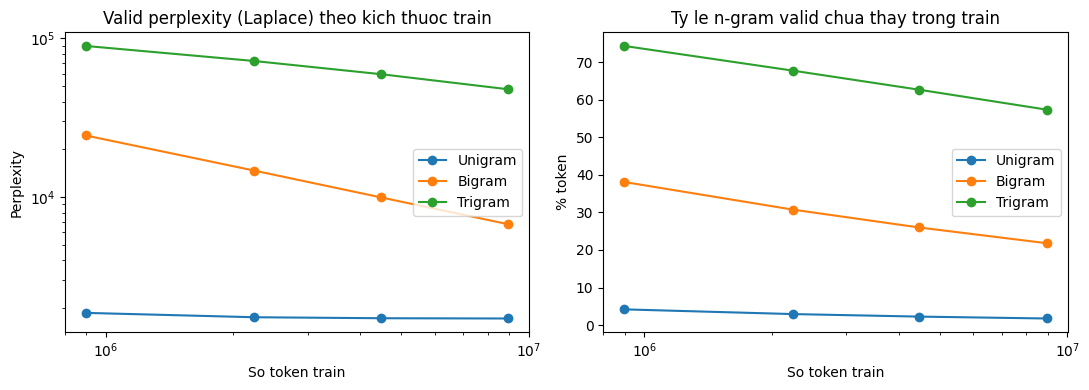

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in ("Unigram", "Bigram", "Trigram"):
    d = size_df[size_df["Model"] == name]
    axes[0].plot(d["Train tokens"], d["Valid PPL (Laplace)"], marker="o", label=name)
    axes[1].plot(d["Train tokens"], d["Valid unseen n-gram %"], marker="o", label=name)
for ax, title, ylab in [(axes[0], "Valid perplexity (Laplace) theo kich thuoc train", "Perplexity"),
                        (axes[1], "Ty le n-gram valid chua thay trong train", "% token")]:
    ax.set_xscale("log")
    ax.set_xlabel("So token train")
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.legend()
axes[0].set_yscale("log")
plt.tight_layout()
plt.show()

## Lưu kết quả vào `results.csv`

In [ ]:
import csv
import os

RESULTS_PATH = os.path.join(os.path.dirname(CORPUS_PATH), "results.csv")

with open(RESULTS_PATH, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([])
    writer.writerow(["experiment", "model", "unique_ngrams", "train_ppl", "valid_ppl", "test_ppl"])
    for _, r in results.iterrows():
        writer.writerow(["exp3_perplexity", r["Model"], r["Unique n-grams"],
                         r["Train PPL"], r["Valid PPL"], r["Test PPL"]])
    writer.writerow([])
    writer.writerow(["experiment", "model", "train_fraction", "train_tokens",
                     "valid_ppl_laplace", "valid_unseen_ngram_pct"])
    for _, r in size_df.iterrows():
        writer.writerow(["exp3_corpus_size", r["Model"], r["Train fraction"], r["Train tokens"],
                         r["Valid PPL (Laplace)"], round(r["Valid unseen n-gram %"], 4)])

print("Da luu:", RESULTS_PATH)

Da luu: /content/drive/MyDrive/NLP/lab02/results.csv
